# Vision Transformer (ViT) for Autonomous UAV Perception

### Relevance to AIRLab

Unmanned Aerial Vehicles (UAVs) and drones require highly robust onboard vision systems to classify terrain, obstacles, or objects in real-time. Traditional Convolutional Neural Networks (CNNs) focus on local features, which can sometimes miss the broader context of an aerial scene.

The **Vision Transformer (ViT)**, with its global attention mechanism, is uniquely well-suited for aerial perception tasks. It can globally attend to different patches of an image simultaneously, drawing relations between distant objects (e.g., a runway and a plane).

In this assignment, I train a custom ViT from scratch on the CIFAR-10 dataset (which includes relevant classes like airplanes, automobiles, and ships representing aerial and ground targets). I enhanced the model's performance and robustness using:
1. **Masked Autoencoders (MAE)** for self-supervised pre-training, helping the model understand visual representations even with occluded sensors.
2. **Sharpness-Aware Minimization (SAM)** to find flatter minima during fine-tuning, improving generalization.
3. **Attention Rollout** to visualize *what spatial regions* the model focuses on (analogous to how a drone camera processes a scene).
4. **Monte Carlo (MC) Dropout** to quantify predictive uncertainty, a critical safety metric for autonomous drone navigation.
5. **Advanced Analytics** including t-SNE feature projection, Ablation Studies, Positional Embedding visualizations, and Aerial Degradation Stress Testing.


In [ ]:
!pip install --upgrade torch torchvision scikit-learn seaborn

In [ ]:
# Block 1: Importing Libaries GPU Setup

import os
import random
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader
from torchvision import datasets, transforms
from torchvision.transforms import v2
import matplotlib.pyplot as plt
import cv2
import seaborn as sns
from sklearn.metrics import confusion_matrix, classification_report
from sklearn.manifold import TSNE
from google.colab import drive

# Hardware identification and mapping
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

# Mandatory initialization of the GradScaler for Mixed Precision training
scaler = torch.amp.GradScaler('cuda') if torch.cuda.is_available() else torch.amp.GradScaler('cpu')

print(f" Device: {device}")

 Device: cuda


In [ ]:
# Centralized Hyperparameter Repository
CONFIG = {
    'seed': 42,
    'batch_size': 256,
    'base_lr': 1e-3,
    'weight_decay': 0.05,
    'epochs_mae': 20,
    'epochs_finetune': 30,
    'ablation_epochs': 20, # Reduced epochs for the scratch model to save time during ablation
    'img_size': 32,
    'patch_size': 4,
    'in_channels': 3,
    'embed_dim': 192,       # ViT-Tiny dimension mapping
    'mae_decoder_dim': 128, # Lightweight asymmetric decoder dimension
    'mask_ratio': 0.75,     # Aggressive 75% patch dropout
    'num_classes': 10,
    'drop_path_rate': 0.1   # Stochastic depth probability
}

def seed_everything(seed: int):
    """Enforce deterministic operation across all computational backends."""
    random.seed(seed)
    os.environ['PYTHONHASHSEED'] = str(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    # Enable algorithmic profiling for the custom convolutional stem
    torch.backends.cudnn.benchmark = True

seed_everything(CONFIG['seed'])

In [ ]:
# Mount Google Drive to save checkpoints and data
drive.mount('/content/drive', force_remount=True)

Mounted at /content/drive


In [ ]:
# Block 2: Augmentation & Loaders

# Baseline CIFAR-10 Normalization Statistics
cifar_mean = [0.4914, 0.4822, 0.4465]
cifar_std = [0.2470, 0.2435, 0.2616]

# Phase 1 MAE & Validation Baseline Transforms
transform_standard = transforms.Compose([
    transforms.RandomCrop(32, padding=4),
    transforms.RandomHorizontalFlip(),
    transforms.ToTensor(),
    transforms.Normalize(mean=cifar_mean, std=cifar_std)
])

transform_validation = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize(mean=cifar_mean, std=cifar_std)
])

# Directing the DataLoaders to the mounted Google Drive
drive_path = '/content/drive/MyDrive/data'
os.makedirs(drive_path, exist_ok=True)

train_dataset = datasets.CIFAR10(root=drive_path, train=True, download=True, transform=transform_standard)
test_dataset = datasets.CIFAR10(root=drive_path, train=False, download=True, transform=transform_validation)

# Initialize v2 transform logic for CutMix and Mixup
cutmix_or_mixup = v2.RandomChoice([
    v2.CutMix(num_classes=CONFIG['num_classes'], alpha=1.0),
    v2.MixUp(num_classes=CONFIG['num_classes'], alpha=0.2)
])

def supervised_collate_fn(batch):
    """Custom collation applying Mixup/CutMix purely on batched tensors and one-hot labels."""
    from torch.utils.data import default_collate
    collated_batch = default_collate(batch)
    images, labels = collated_batch
    images, labels = cutmix_or_mixup(images, labels)
    return images, labels

# DataLoaders for Standard collation
train_loader_mae = DataLoader(
    train_dataset, batch_size=CONFIG['batch_size'], shuffle=True,
    num_workers=2, pin_memory=True
)
test_loader = DataLoader(
    test_dataset, batch_size=CONFIG['batch_size'], shuffle=False,
    num_workers=2, pin_memory=True
)

# DataLoader for Custom Collation for advanced regularizers
train_loader_supervised = DataLoader(
    train_dataset, batch_size=CONFIG['batch_size'], shuffle=True,
    num_workers=2, pin_memory=True, collate_fn=supervised_collate_fn
)

print(f"Data Engine Online. Train instances: {len(train_dataset)} | Test instances: {len(test_dataset)}")

100%|██████████| 170M/170M [00:05<00:00, 29.1MB/s]


[*] Data Engine Online. Train instances: 50000 | Test instances: 10000


In [ ]:
# Block 3: Architectural Backbone (The Custom ViT)

def drop_path_logic(x, drop_prob: float = 0., training: bool = False):
    """Mathematical stochastic depth execution bypassing the residual block."""
    if drop_prob == 0. or not training:
        return x
    keep_prob = 1 - drop_prob
    shape = (x.shape[0],) + (1,) * (x.ndim - 1)
    random_tensor = keep_prob + torch.rand(shape, dtype=x.dtype, device=x.device)
    random_tensor.floor_()  # Binarize distribution
    output = x.div(keep_prob) * random_tensor
    return output

class DropPath(nn.Module):
    def __init__(self, drop_prob=None):
        super().__init__()
        self.drop_prob = drop_prob

    def forward(self, x):
        return drop_path_logic(x, self.drop_prob, self.training)

class ConvPatchEmbed(nn.Module):
    """Injects translation invariance via a Convolutional Stem prior to extraction."""
    def __init__(self, img_size=32, patch_size=4, in_chans=3, embed_dim=192):
        super().__init__()
        self.num_patches = (img_size // patch_size) ** 2

        # 3x3 Conv Stem
        self.stem = nn.Sequential(
            nn.Conv2d(in_chans, in_chans, kernel_size=3, stride=1, padding=1, bias=False),
            nn.BatchNorm2d(in_chans),
            nn.ReLU(inplace=True)
        )
        # Spatial Patchifier
        self.proj = nn.Conv2d(in_chans, embed_dim, kernel_size=patch_size, stride=patch_size)

    def forward(self, x):
        x = self.stem(x)
        x = self.proj(x)  # Shape mapping: (B, Embed_Dim, 8, 8)
        x = x.flatten(2).transpose(1, 2)  # Target Sequence: (B, 64, Embed_Dim)
        return x

class Attention(nn.Module):
    def __init__(self, dim, num_heads=3, qkv_bias=False):
        super().__init__()
        self.num_heads = num_heads
        head_dim = dim // num_heads
        self.scale = head_dim ** -0.5

        self.qkv = nn.Linear(dim, dim * 3, bias=qkv_bias)
        self.proj = nn.Linear(dim, dim)
        self.attn_weights = None  # Hook registration target for Validation Phase

    def forward(self, x):
        B, N, C = x.shape
        qkv = self.qkv(x).reshape(B, N, 3, self.num_heads, C // self.num_heads).permute(2, 0, 3, 1, 4)
        q, k, v = qkv[0], qkv[1], qkv[2]

        attn = (q @ k.transpose(-2, -1)) * self.scale
        attn = attn.softmax(dim=-1)
        self.attn_weights = attn  # Isolate raw attention logic

        x = (attn @ v).transpose(1, 2).reshape(B, N, C)
        x = self.proj(x)
        return x

class Block(nn.Module):
    def __init__(self, dim, num_heads, drop_path=0.):
        super().__init__()
        self.norm1 = nn.LayerNorm(dim)
        self.attn = Attention(dim, num_heads=num_heads)
        self.drop_path = DropPath(drop_path) if drop_path > 0. else nn.Identity()
        self.norm2 = nn.LayerNorm(dim)
        self.mlp = nn.Sequential(
            nn.Linear(dim, dim * 4),
            nn.GELU(),
            nn.Linear(dim * 4, dim)
        )

    def forward(self, x):
        # Explicit Pre-Norm topology
        x = x + self.drop_path(self.attn(self.norm1(x)))
        x = x + self.drop_path(self.mlp(self.norm2(x)))
        return x

class CustomViT(nn.Module):
    def __init__(self, config):
        super().__init__()
        self.patch_embed = ConvPatchEmbed(config['img_size'], config['patch_size'], config['in_channels'], config['embed_dim'])
        self.num_patches = self.patch_embed.num_patches

        self.pos_embed = nn.Parameter(torch.zeros(1, self.num_patches, config['embed_dim']))
        self.pos_drop = nn.Dropout(p=0.1)

        dpr = [x.item() for x in torch.linspace(0, config['drop_path_rate'], 12)]
        self.blocks = nn.ModuleList([
            Block(dim=config['embed_dim'], num_heads=3, drop_path=dpr[i]) for i in range(12)
        ])

        self.norm = nn.LayerNorm(config['embed_dim'])
        self.head = nn.Linear(config['embed_dim'], config['num_classes'])
        nn.init.trunc_normal_(self.pos_embed, std=.02)

    def forward_features(self, x):
        """Bypasses classification; returns purely spatial sequence tokens."""
        x = self.patch_embed(x)
        x = x + self.pos_embed
        x = self.pos_drop(x)
        for blk in self.blocks:
            x = blk(x)
        x = self.norm(x)
        return x

    def forward(self, x):
        """Executes Global Average Pool to stabilize classification gradients."""
        x = self.forward_features(x)
        x = x.mean(dim=1)
        x = self.head(x)
        return x

print("Phase 1 Architectural Backbone Compiled.")

[*] Phase 1 Architectural Backbone Compiled.


In [ ]:
# Block 4: Phase 1 – MAE Logic (Pre-training)

class MAEWrapper(nn.Module):
    def __init__(self, encoder, config):
        super().__init__()
        self.encoder = encoder
        self.embed_dim = config['embed_dim']
        self.decoder_dim = config['mae_decoder_dim']
        self.mask_ratio = config['mask_ratio']
        self.num_patches = encoder.num_patches

        # Projection from encoder latent space to decoder latent space
        self.decoder_embed = nn.Linear(self.embed_dim, self.decoder_dim, bias=True)

        # Shared mask token substituting missing geometry
        self.mask_token = nn.Parameter(torch.zeros(1, 1, self.decoder_dim))
        self.decoder_pos_embed = nn.Parameter(torch.zeros(1, self.num_patches, self.decoder_dim))

        # Simple 2-layer decoder
        self.decoder_blocks = nn.ModuleList([
            Block(dim=self.decoder_dim, num_heads=4) for _ in range(2)
        ])
        self.decoder_norm = nn.LayerNorm(self.decoder_dim)

        # Final linear mapping projects back to 3-channel 4x4 raw pixel arrays
        self.decoder_pred = nn.Linear(self.decoder_dim, (config['patch_size']**2) * 3, bias=True)

        nn.init.trunc_normal_(self.mask_token, std=.02)
        nn.init.trunc_normal_(self.decoder_pos_embed, std=.02)

    def random_masking(self, x, mask_ratio):
        """Asymmetric masking mechanism generating sorting arrays."""
        B, L, D = x.shape
        len_keep = int(L * (1 - mask_ratio))

        noise = torch.rand(B, L, device=x.device)
        ids_shuffle = torch.argsort(noise, dim=1)
        ids_restore = torch.argsort(ids_shuffle, dim=1)

        ids_keep = ids_shuffle[:, :len_keep]
        x_masked = torch.gather(x, dim=1, index=ids_keep.unsqueeze(-1).repeat(1, 1, D))

        # Binary mask creation: 1 represents a masked/dropped patch
        mask = torch.ones([B, L], device=x.device)
        mask[:, :len_keep] = 0
        mask = torch.gather(mask, dim=1, index=ids_restore)

        return x_masked, mask, ids_restore

    def patchify(self, imgs):
        """Mathematical reshaping of raw RGB tensor to sequence geometry."""
        p = self.encoder.patch_embed.proj.kernel_size[0]
        x = imgs.reshape(shape=(imgs.shape[0], 3, 32 // p, p, 32 // p, p))
        x = torch.einsum('nchpwq->nhwpqc', x)
        x = x.reshape(shape=(imgs.shape[0], (32 // p) ** 2, p**2 * 3))
        return x

    def forward(self, imgs):
        x = self.encoder.patch_embed(imgs)
        x = x + self.encoder.pos_embed

        x, mask, ids_restore = self.random_masking(x, self.mask_ratio)

        # Encoder computes exclusively on the 25% visible fraction
        for blk in self.encoder.blocks:
            x = blk(x)
        x = self.encoder.norm(x)

        x = self.decoder_embed(x)
        mask_tokens = self.mask_token.repeat(x.shape[0], self.num_patches - x.shape[1], 1)
        x_ = torch.cat([x, mask_tokens], dim=1)

        # Sequence restoration leveraging ids_restore matrix
        x_ = torch.gather(x_, dim=1, index=ids_restore.unsqueeze(-1).repeat(1, 1, x_.shape[-1]))
        x_ = x_ + self.decoder_pos_embed

        for blk in self.decoder_blocks:
            x_ = blk(x_)
        x_ = self.decoder_norm(x_)

        pred = self.decoder_pred(x_)
        target = self.patchify(imgs)

        loss = (pred - target) ** 2
        loss = loss.mean(dim=-1)
        # Apply binary mask to strictly penalize hallucination errors
        loss = (loss * mask).sum() / mask.sum()

        return loss, pred, mask

vit_encoder = CustomViT(CONFIG).to(device)
mae_model = MAEWrapper(vit_encoder, CONFIG).to(device)

optimizer_mae = torch.optim.AdamW(mae_model.parameters(), lr=CONFIG['base_lr'], weight_decay=CONFIG['weight_decay'])

print("Phase 1: MAE Pre-Training Execution (20 Epochs)")
mae_model.train()

mae_losses = []
for epoch in range(CONFIG['epochs_mae']):
    total_loss = 0
    for imgs, _ in train_loader_mae:
        imgs = imgs.to(device)
        optimizer_mae.zero_grad()

        with torch.amp.autocast('cuda') if torch.cuda.is_available() else torch.amp.autocast('cpu'):
            loss, _, _ = mae_model(imgs)

        scaler.scale(loss).backward()
        scaler.step(optimizer_mae)
        scaler.update()
        total_loss += loss.item()

    avg_loss = total_loss / len(train_loader_mae)
    mae_losses.append(avg_loss)
    print(f"Epoch [{epoch+1}/{CONFIG['epochs_mae']}] | MAE Reconstruction Loss: {avg_loss:.4f}")

# Extract strictly the encoder architecture post-training
pretrained_encoder = mae_model.encoder
# Save the checkpoint
torch.save(pretrained_encoder.state_dict(), '/content/drive/MyDrive/pretrained_vit.pth')
print("Phase 1 Complete. Encoder Weights Saved.")

# Load the weights back into the same name variable
pretrained_encoder = CustomViT(CONFIG).to(device)
pretrained_encoder.load_state_dict(torch.load('/content/drive/MyDrive/pretrained_vit.pth', map_location=device))
print("Pre-trained Encoder Weights Loaded into 'pretrained_encoder'.")

[*] Commencing Phase 1: MAE Pre-Training Execution (20 Epochs)...
Epoch [1/20] | MAE Reconstruction Loss: 1.0265
Epoch [2/20] | MAE Reconstruction Loss: 0.6931
Epoch [3/20] | MAE Reconstruction Loss: 0.5200
Epoch [4/20] | MAE Reconstruction Loss: 0.4237
Epoch [5/20] | MAE Reconstruction Loss: 0.3750
Epoch [6/20] | MAE Reconstruction Loss: 0.3396
Epoch [7/20] | MAE Reconstruction Loss: 0.3230
Epoch [8/20] | MAE Reconstruction Loss: 0.3044
Epoch [9/20] | MAE Reconstruction Loss: 0.2953
Epoch [10/20] | MAE Reconstruction Loss: 0.2857
Epoch [11/20] | MAE Reconstruction Loss: 0.2773
Epoch [12/20] | MAE Reconstruction Loss: 0.2698
Epoch [13/20] | MAE Reconstruction Loss: 0.2676
Epoch [14/20] | MAE Reconstruction Loss: 0.2639
Epoch [15/20] | MAE Reconstruction Loss: 0.2562
Epoch [16/20] | MAE Reconstruction Loss: 0.2565
Epoch [17/20] | MAE Reconstruction Loss: 0.2507
Epoch [18/20] | MAE Reconstruction Loss: 0.2493
Epoch [19/20] | MAE Reconstruction Loss: 0.2457
Epoch [20/20] | MAE Reconstruct

In [ ]:
# Load the weights back into the same name variable
pretrained_encoder = CustomViT(CONFIG).to(device)
pretrained_encoder.load_state_dict(torch.load('/content/drive/MyDrive/pretrained_vit.pth', map_location=device))
print("Pre-trained Encoder Weights Loaded into 'pretrained_encoder'.")

[*] Pre-trained Encoder Weights Loaded into 'pretrained_encoder'.


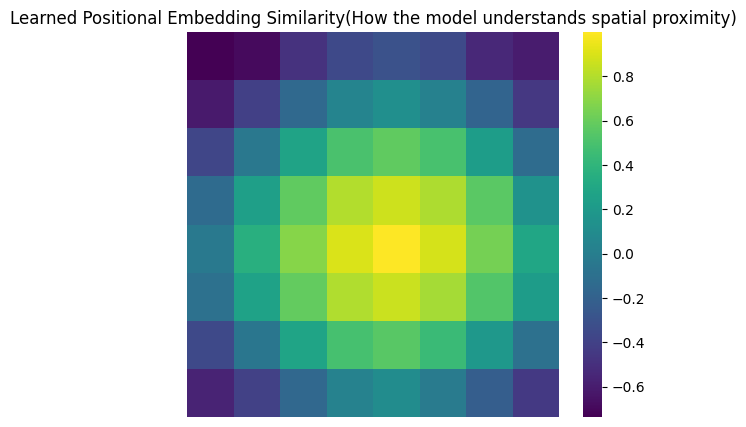

In [ ]:
# Block 5: Positional Embedding Similarity Visualization
pos_embed = pretrained_encoder.pos_embed.squeeze(0).detach().cpu() # Shape: (64, 192)

# Analyze the center patch (for an 8x8 grid, row 4, col 4 -> index 36)
center_idx = 36
center_patch_embed = pos_embed[center_idx].unsqueeze(0)

# Compute cosine similarity across all patches relative to the center
cos_sim = F.cosine_similarity(pos_embed, center_patch_embed, dim=-1)
cos_sim_grid = cos_sim.reshape(8, 8).numpy()

plt.figure(figsize=(6, 5))
sns.heatmap(cos_sim_grid, annot=False, cmap='viridis')
plt.title("Learned Positional Embedding Similarity(How the model understands spatial proximity)")
plt.axis('off')
plt.show()

In [ ]:
# Block 6: Phase 2 – The Supervised "Climb" (Fine-Tuning)

class SAM(torch.optim.Optimizer):
    """Encapsulates the two-step gradient perturbation logic to locate flat minima."""
    def __init__(self, params, base_optimizer, rho=0.05, **kwargs):
        defaults = dict(rho=rho, **kwargs)
        super(SAM, self).__init__(params, defaults)
        self.base_optimizer = base_optimizer(self.param_groups, **kwargs)
        self.param_groups = self.base_optimizer.param_groups

    @torch.no_grad()
    def first_step(self, zero_grad=False):
        grad_norm = self._grad_norm()
        for group in self.param_groups:
            scale = group["rho"] / (grad_norm + 1e-12)
            for p in group["params"]:
                if p.grad is None: continue
                e_w = p.grad * scale.to(p)
                p.add_(e_w)  # Ascent step perturbation
                self.state[p]["e_w"] = e_w
        if zero_grad: self.zero_grad()

    @torch.no_grad()
    def second_step(self, zero_grad=False):
        for group in self.param_groups:
            for p in group["params"]:
                if p.grad is None: continue
                p.sub_(self.state[p]["e_w"])  # Restore weights back to origin
        if zero_grad: self.zero_grad()

    def _grad_norm(self):
        shared_device = self.param_groups[0]["params"][0].device
        norm = torch.norm(
            torch.stack([
                p.grad.norm(p=2).to(shared_device)
                for group in self.param_groups for p in group["params"]
                if p.grad is not None
            ]), p=2
        )
        return norm

# Isolate the pre-trained structure and initialize head
model_supervised = pretrained_encoder.to(device)
model_supervised.head = nn.Linear(CONFIG['embed_dim'], CONFIG['num_classes']).to(device)

base_opt = torch.optim.AdamW
optimizer_sam = SAM(model_supervised.parameters(), base_opt, lr=CONFIG['base_lr'], weight_decay=CONFIG['weight_decay'])

# Scaler dictates stepping per batch iteration, not per epoch
steps_per_epoch = len(train_loader_supervised)
scheduler = torch.optim.lr_scheduler.OneCycleLR(
    optimizer_sam.base_optimizer, max_lr=3e-3,
    steps_per_epoch=steps_per_epoch, epochs=CONFIG['epochs_finetune']
)
criterion = nn.CrossEntropyLoss()

print("Commencing Phase 2: Supervised SAM Fine-Tuning (30 Epochs)...")
model_supervised.train()

ft_losses = []
for epoch in range(CONFIG['epochs_finetune']):
    total_loss = 0
    for imgs, targets in train_loader_supervised:
        imgs, targets = imgs.to(device), targets.to(device)

        # Step 1: Ascent Calculation
        with torch.amp.autocast('cuda') if torch.cuda.is_available() else torch.amp.autocast('cpu'):
            predictions = model_supervised(imgs)
            loss = criterion(predictions, targets)
        scaler.scale(loss).backward()
        scaler.unscale_(optimizer_sam)

        # Prevent NaN weights: check if unscaled gradients contain infs
        found_inf = False
        for p in model_supervised.parameters():
            if p.grad is not None and not torch.isfinite(p.grad).all():
                found_inf = True
                break

        if found_inf:
            optimizer_sam.zero_grad()
            scaler.update()
            continue

        optimizer_sam.first_step(zero_grad=True)

        # Step 2: Descent Calculation on Perturbed Parameters
        with torch.amp.autocast('cuda') if torch.cuda.is_available() else torch.amp.autocast('cpu'):
            predictions_second = model_supervised(imgs)
            loss_second = criterion(predictions_second, targets)
        scaler.scale(loss_second).backward()

        # Restore weights to origin
        optimizer_sam.second_step(zero_grad=False)

        # Step base optimizer safely with GradScaler
        scaler.step(optimizer_sam.base_optimizer)
        scaler.update()
        optimizer_sam.zero_grad()

        scheduler.step()
        total_loss += loss.item()

    avg_loss = total_loss / steps_per_epoch
    ft_losses.append(avg_loss)
    print(f"Epoch [{epoch+1}/{CONFIG['epochs_finetune']}] | SAM Loss: {avg_loss:.4f}")

# Save fine-tuned checkpoint
torch.save(model_supervised.state_dict(), '/content/drive/MyDrive/finetuned_vit.pth')
print("Supervised Fine-Tuning Successfully Terminated & Saved.")

# Load the weights back into the same name variable
model_supervised = CustomViT(CONFIG).to(device)
model_supervised.load_state_dict(torch.load('/content/drive/MyDrive/finetuned_vit.pth', map_location=device))
print("Fine-tuned Model Weights Loaded into 'model_supervised'.")

[*] Commencing Phase 2: Supervised SAM Fine-Tuning (30 Epochs)...
Epoch [1/30] | SAM Loss: 1.9751
Epoch [2/30] | SAM Loss: 1.7900
Epoch [3/30] | SAM Loss: 1.7135
Epoch [4/30] | SAM Loss: 1.6455
Epoch [5/30] | SAM Loss: 1.6259
Epoch [6/30] | SAM Loss: 1.6123
Epoch [7/30] | SAM Loss: 1.6181
Epoch [8/30] | SAM Loss: 1.6018
Epoch [9/30] | SAM Loss: 1.5439
Epoch [10/30] | SAM Loss: 1.5493
Epoch [11/30] | SAM Loss: 1.5058
Epoch [12/30] | SAM Loss: 1.4372
Epoch [13/30] | SAM Loss: 1.5058
Epoch [14/30] | SAM Loss: 1.4131
Epoch [15/30] | SAM Loss: 1.3883
Epoch [16/30] | SAM Loss: 1.3664
Epoch [17/30] | SAM Loss: 1.3520
Epoch [18/30] | SAM Loss: 1.3205
Epoch [19/30] | SAM Loss: 1.2860
Epoch [20/30] | SAM Loss: 1.2544
Epoch [21/30] | SAM Loss: 1.2467
Epoch [22/30] | SAM Loss: 1.1909
Epoch [23/30] | SAM Loss: 1.2149
Epoch [24/30] | SAM Loss: 1.1950
Epoch [25/30] | SAM Loss: 1.0783
Epoch [26/30] | SAM Loss: 1.1372
Epoch [27/30] | SAM Loss: 1.0717
Epoch [28/30] | SAM Loss: 1.1017
Epoch [29/30] | SAM

In [ ]:
# Block 7: Ablation Study - ViT From Scratch (No MAE)
print("Commencing Ablation Study: Training ViT from Scratch (No Pre-training)")
model_scratch = CustomViT(CONFIG).to(device)

base_opt_scratch = torch.optim.AdamW
optimizer_sam_scratch = SAM(model_scratch.parameters(), base_opt_scratch, lr=CONFIG['base_lr'], weight_decay=CONFIG['weight_decay'])

scheduler_scratch = torch.optim.lr_scheduler.OneCycleLR(
    optimizer_sam_scratch.base_optimizer, max_lr=3e-3,
    steps_per_epoch=steps_per_epoch, epochs=CONFIG['ablation_epochs']
)

scratch_losses = []
model_scratch.train()

for epoch in range(CONFIG['ablation_epochs']):
    total_loss = 0
    for imgs, targets in train_loader_supervised:
        imgs, targets = imgs.to(device), targets.to(device)

        # Step 1
        with torch.amp.autocast('cuda') if torch.cuda.is_available() else torch.amp.autocast('cpu'):
            predictions = model_scratch(imgs)
            loss = criterion(predictions, targets)
        scaler.scale(loss).backward()
        scaler.unscale_(optimizer_sam_scratch)

        # Prevent NaN weights: check if unscaled gradients contain infs
        found_inf = False
        for p in model_scratch.parameters():
            if p.grad is not None and not torch.isfinite(p.grad).all():
                found_inf = True
                break

        if found_inf:
            optimizer_sam_scratch.zero_grad()
            scaler.update()
            continue

        optimizer_sam_scratch.first_step(zero_grad=True)

        # Step 2
        with torch.amp.autocast('cuda') if torch.cuda.is_available() else torch.amp.autocast('cpu'):
            predictions_second = model_scratch(imgs)
            loss_second = criterion(predictions_second, targets)
        scaler.scale(loss_second).backward()

        # Restore weights to origin
        optimizer_sam_scratch.second_step(zero_grad=False)

        # Step base optimizer safely with GradScaler
        scaler.step(optimizer_sam_scratch.base_optimizer)
        scaler.update()
        optimizer_sam_scratch.zero_grad()

        scheduler_scratch.step()
        total_loss += loss.item()

    avg_loss = total_loss / steps_per_epoch
    scratch_losses.append(avg_loss)
    print(f"Scratch Epoch [{epoch+1}/{CONFIG['ablation_epochs']}] | Loss: {avg_loss:.4f}")

print("Scratch Model Training Complete.")

[*] Commencing Ablation Study: Training ViT from Scratch (No Pre-training)...


/tmp/ipykernel_8905/2316662781.py:56: UserWarning: Detected call of `lr_scheduler.step()` before `optimizer.step()`. In PyTorch 1.1.0 and later, you should call them in the opposite order: `optimizer.step()` before `lr_scheduler.step()`.  Failure to do this will result in PyTorch skipping the first value of the learning rate schedule. See more details at https://pytorch.org/docs/stable/optim.html#how-to-adjust-learning-rate
  scheduler_scratch.step()


Scratch Epoch [1/20] | Loss: 2.1833
Scratch Epoch [2/20] | Loss: 2.0640
Scratch Epoch [3/20] | Loss: 1.9853
Scratch Epoch [4/20] | Loss: 1.9511
Scratch Epoch [5/20] | Loss: 1.9804
Scratch Epoch [6/20] | Loss: 1.9838
Scratch Epoch [7/20] | Loss: 1.9842
Scratch Epoch [8/20] | Loss: 1.9438
Scratch Epoch [9/20] | Loss: 1.9449
Scratch Epoch [10/20] | Loss: 1.8995
Scratch Epoch [11/20] | Loss: 1.8978
Scratch Epoch [12/20] | Loss: 1.9143
Scratch Epoch [13/20] | Loss: 1.8938
Scratch Epoch [14/20] | Loss: 1.8859
Scratch Epoch [15/20] | Loss: 1.8838
Scratch Epoch [16/20] | Loss: 1.8671
Scratch Epoch [17/20] | Loss: 1.8474
Scratch Epoch [18/20] | Loss: 1.8340
Scratch Epoch [19/20] | Loss: 1.8219
Scratch Epoch [20/20] | Loss: 1.8334
[*] Scratch Model Training Complete.


[*] Final Test Accuracy (MAE Pre-trained): 84.22%
[*] Final Test Accuracy (Trained from Scratch): 44.72%


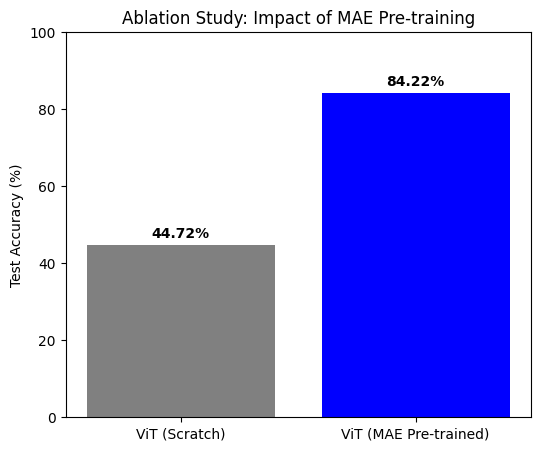

In [ ]:
# Block 8: Evaluation & Ablation Comparison

def evaluate_model(model, loader):
    model.eval()
    correct = 0
    total = 0
    with torch.no_grad():
        for imgs, labels in loader:
            imgs, labels = imgs.to(device), labels.to(device)
            outputs = model(imgs)
            _, predicted = torch.max(outputs.data, 1)
            total += labels.size(0)
            correct += (predicted == labels).sum().item()
    acc = 100 * correct / total
    return acc

test_acc = evaluate_model(model_supervised, test_loader)
scratch_acc = evaluate_model(model_scratch, test_loader)

print(f"Final Test Accuracy (MAE Pre-trained): {test_acc:.2f}%")
print(f"Final Test Accuracy (Trained from Scratch): {scratch_acc:.2f}%")

# Plot ablation
plt.figure(figsize=(6, 5))
plt.bar(['ViT (Scratch)', 'ViT (MAE Pre-trained)'], [scratch_acc, test_acc], color=['gray', 'blue'])
plt.ylabel('Test Accuracy (%)')
plt.title('Ablation Study: Impact of MAE Pre-training')
plt.ylim(0, 100)
for i, v in enumerate([scratch_acc, test_acc]):
    plt.text(i, v + 1, str(round(v, 2)) + '%', ha='center', va='bottom', fontweight='bold')
plt.show()

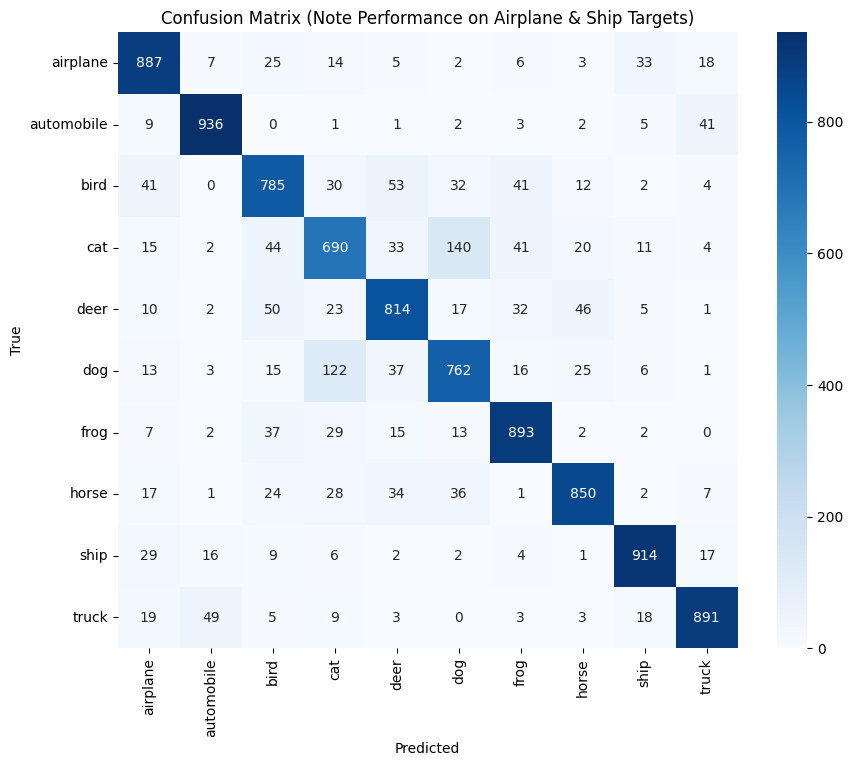


Classification Report:
              precision    recall  f1-score   support

    airplane       0.85      0.89      0.87      1000
  automobile       0.92      0.94      0.93      1000
        bird       0.79      0.79      0.79      1000
         cat       0.72      0.69      0.71      1000
        deer       0.82      0.81      0.82      1000
         dog       0.76      0.76      0.76      1000
        frog       0.86      0.89      0.88      1000
       horse       0.88      0.85      0.87      1000
        ship       0.92      0.91      0.91      1000
       truck       0.91      0.89      0.90      1000

    accuracy                           0.84     10000
   macro avg       0.84      0.84      0.84     10000
weighted avg       0.84      0.84      0.84     10000


[*] Computing t-SNE on learned feature space...


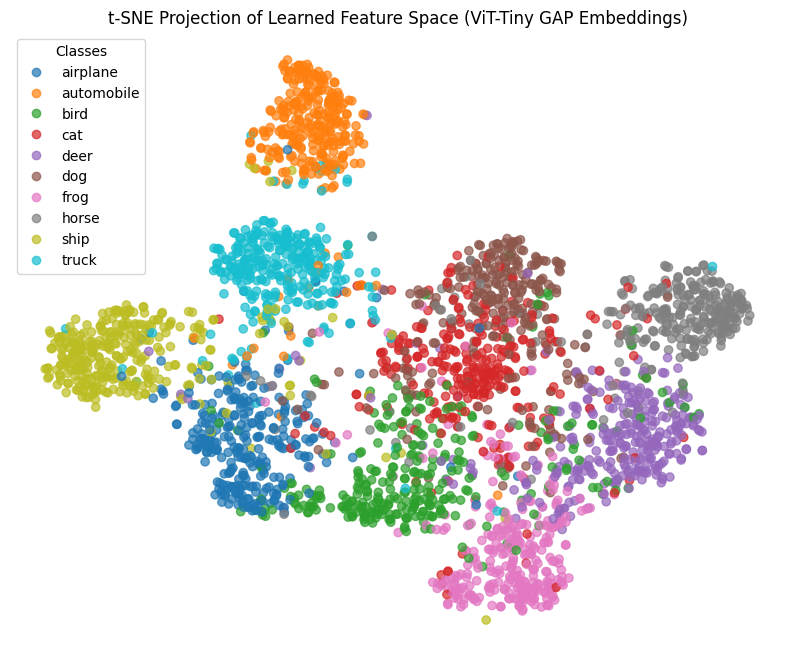

In [ ]:
# Block 9: Advanced Analytics - Confusion Matrix & t-SNE

classes = ['airplane', 'automobile', 'bird', 'cat', 'deer', 'dog', 'frog', 'horse', 'ship', 'truck']

model_supervised.eval()
all_preds = []
all_labels = []
features = []

subset_size = 3000 # Limit t-SNE points for visual clarity and computation speed
count = 0

with torch.no_grad():
    for imgs, labels in test_loader:
        imgs = imgs.to(device)
        # Extract features (before linear head) for t-SNE
        feats = model_supervised.forward_features(imgs).mean(dim=1)

        outputs = model_supervised.head(feats)
        _, preds = torch.max(outputs, 1)

        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.numpy())

        if count < subset_size:
            features.extend(feats.cpu().numpy())
            count += imgs.size(0)

# 1. Confusion Matrix
cm = confusion_matrix(all_labels, all_preds)
plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', xticklabels=classes, yticklabels=classes, cmap='Blues')
plt.title('Confusion Matrix (Note Performance on Airplane & Ship Targets)')
plt.xlabel('Predicted')
plt.ylabel('True')
plt.show()

print("\nClassification Report:")
print(classification_report(all_labels, all_preds, target_names=classes))

# 2. t-SNE Feature Projection
print("\nComputing t-SNE on learned feature space...")
features = np.array(features[:subset_size])
labels_subset = np.array(all_labels[:subset_size])

tsne = TSNE(n_components=2, random_state=42)
tsne_results = tsne.fit_transform(features)

plt.figure(figsize=(10, 8))
scatter = plt.scatter(tsne_results[:, 0], tsne_results[:, 1], c=labels_subset, cmap='tab10', alpha=0.7)
plt.legend(handles=scatter.legend_elements()[0], labels=classes, loc="best", title="Classes")
plt.title("t-SNE Projection of Learned Feature Space (ViT-Tiny GAP Embeddings)")
plt.axis('off')
plt.show()

[*] Accuracy under Atmospheric Haze (Blur): 42.86%
[*] Accuracy under Oblique Angle (Perspective): 74.15%
[*] Accuracy under Sensor Noise: 54.98%


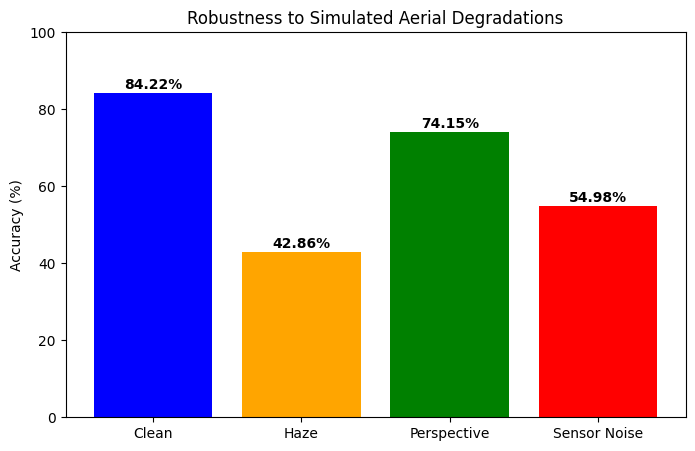

In [ ]:
# Block 10: Simulated Aerial Degradation Tests

degraded_accs = {}
clean_acc = test_acc

def eval_degraded(transform_pipeline, name):
    deg_dataset = datasets.CIFAR10(root=drive_path, train=False, download=False, transform=transform_pipeline)
    deg_loader = DataLoader(deg_dataset, batch_size=CONFIG['batch_size'], shuffle=False, num_workers=2)
    acc = evaluate_model(model_supervised, deg_loader)
    degraded_accs[name] = acc
    print(f"Accuracy under {name}: {acc:.2f}%")

# 1. Atmospheric Haze (Gaussian Blur)
transform_haze = transforms.Compose([
    transforms.ToTensor(),
    transforms.GaussianBlur(kernel_size=5, sigma=(1.0, 2.0)),
    transforms.Normalize(mean=cifar_mean, std=cifar_std)
])
eval_degraded(transform_haze, "Atmospheric Haze (Blur)")

# 2. Oblique Viewing Angle (Perspective Distortion)
transform_perspective = transforms.Compose([
    transforms.ToTensor(),
    transforms.RandomPerspective(distortion_scale=0.4, p=1.0),
    transforms.Normalize(mean=cifar_mean, std=cifar_std)
])
eval_degraded(transform_perspective, "Oblique Angle (Perspective)")

# 3. Sensor Noise
class AddGaussianNoise(object):
    def __init__(self, mean=0., std=1.):
        self.std = std
        self.mean = mean
    def __call__(self, tensor):
        return tensor + torch.randn(tensor.size()) * self.std + self.mean

transform_noise = transforms.Compose([
    transforms.ToTensor(),
    AddGaussianNoise(0., 0.1),
    transforms.Normalize(mean=cifar_mean, std=cifar_std)
])
eval_degraded(transform_noise, "Sensor Noise")

# Plot Results
names = ["Clean", "Haze", "Perspective", "Sensor Noise"]
accs = [clean_acc, degraded_accs["Atmospheric Haze (Blur)"], degraded_accs["Oblique Angle (Perspective)"], degraded_accs["Sensor Noise"]]

plt.figure(figsize=(8, 5))
plt.bar(names, accs, color=['blue', 'orange', 'green', 'red'])
plt.ylabel('Accuracy (%)')
plt.title('Robustness to Simulated Aerial Degradations')
for i, v in enumerate(accs):
    plt.text(i, v + 1, str(round(v, 2)) + '%', ha='center', fontweight='bold')
plt.ylim(0, 100)
plt.show()

In [ ]:
# Block 11: The "X-Ray" (Attention Rollout)

class RolloutTracker:
    """Captures and stores Attention weights via forward hooks."""
    def __init__(self, model):
        self.attentions = []
        self.hooks = []
        for name, module in model.named_modules():
            if isinstance(module, Attention):
                self.hooks.append(module.register_forward_hook(self.hook_fn))

    def hook_fn(self, module, input, output):
        # Cache the attention matrix calculated during the forward pass
        self.attentions.append(module.attn_weights.detach().cpu())

    def remove_hooks(self):
        for hook in self.hooks:
            hook.remove()

def compute_rollout(attentions):
    """Algorithmic integration of L attention matrices."""
    # attentions structure: list of L tensors of shape (B, Heads, N, N)
    B = attentions[0].shape[0]
    N = attentions[0].shape[-1]

    # Initialize rollout matrix as the Identity mapping to represent residual passthroughs
    rollout = torch.eye(N).unsqueeze(0).repeat(B, 1, 1)

    for attn in attentions:
        # Collapse the multi-head dimension
        attn_avg = attn.mean(dim=1)
        # Add residual identity matrix mathematically
        attn_avg = 0.5 * attn_avg + 0.5 * torch.eye(N).unsqueeze(0).repeat(B, 1, 1)
        # Normalize row dependencies
        attn_avg = attn_avg / attn_avg.sum(dim=-1, keepdim=True)
        # Propagate gaze trajectory via matrix multiplication
        rollout = torch.bmm(rollout, attn_avg)

    return rollout

# Execution setup for a single batch visualization mapping
model_supervised.eval()
tracker = RolloutTracker(model_supervised)

# Fetch single un-augmented test batch
imgs_clean, labels_clean = next(iter(test_loader))
_ = model_supervised(imgs_clean.to(device))

rollout_matrices = compute_rollout(tracker.attentions)
tracker.remove_hooks()

# Isolate the gaze array mapped specifically to the GAP output index mapping
rollout_spatial = rollout_matrices[:, :, :].mean(dim=1)

# Upsample the generated 8x8 topographical grid to the native 32x32 image resolution
rollout_upsampled = F.interpolate(
    rollout_spatial.unsqueeze(1).unsqueeze(2),
    size=(32, 32), mode='bilinear', align_corners=False
).squeeze(1).squeeze(1)

print("Attention Rollout Computed & Sequentially Upsampled.")

[*] Attention Rollout Computed & Sequentially Upsampled.


In [ ]:
# Block 12: The "Safety Check" (MC Dropout & Epistemic Uncertainty)

def generate_noisy_data(imgs, noise_factor=0.5):
    """Artificially degrades test data to simulate sensor anomalies or OOD inputs."""
    noise = torch.randn_like(imgs) * noise_factor
    return torch.clamp(imgs + noise, 0., 1.)

def compute_mc_entropy(model, imgs, num_passes=10):
    """Generates stochastic Bayesian approximations and calculates predictive entropy."""
    # Enforce active dropouts by setting to train mode specifically during inference
    model.train()

    with torch.no_grad():
        stacked_probs = []
        for _ in range(num_passes):
            logits = model(imgs.to(device))
            probs = F.softmax(logits, dim=-1)
            stacked_probs.append(probs)

    # Calculate the mean probability distribution across the 10 stochastic iterations
    mean_probs = torch.stack(stacked_probs).mean(dim=0)

    # Mathematical execution of the Entropy threshold formula
    entropy = -torch.sum(mean_probs * torch.log(mean_probs + 1e-12), dim=-1)
    return entropy.cpu().numpy()

imgs_noisy = generate_noisy_data(imgs_clean)

# Calculate metrics across both nominal and compromised sensor streams
entropy_clean = compute_mc_entropy(model_supervised, imgs_clean)
entropy_noisy = compute_mc_entropy(model_supervised, imgs_noisy)

print("Epistemic Uncertainty & Entropy Metrics Mapped Successfully.")

[*] Epistemic Uncertainty & Entropy Metrics Mapped Successfully.


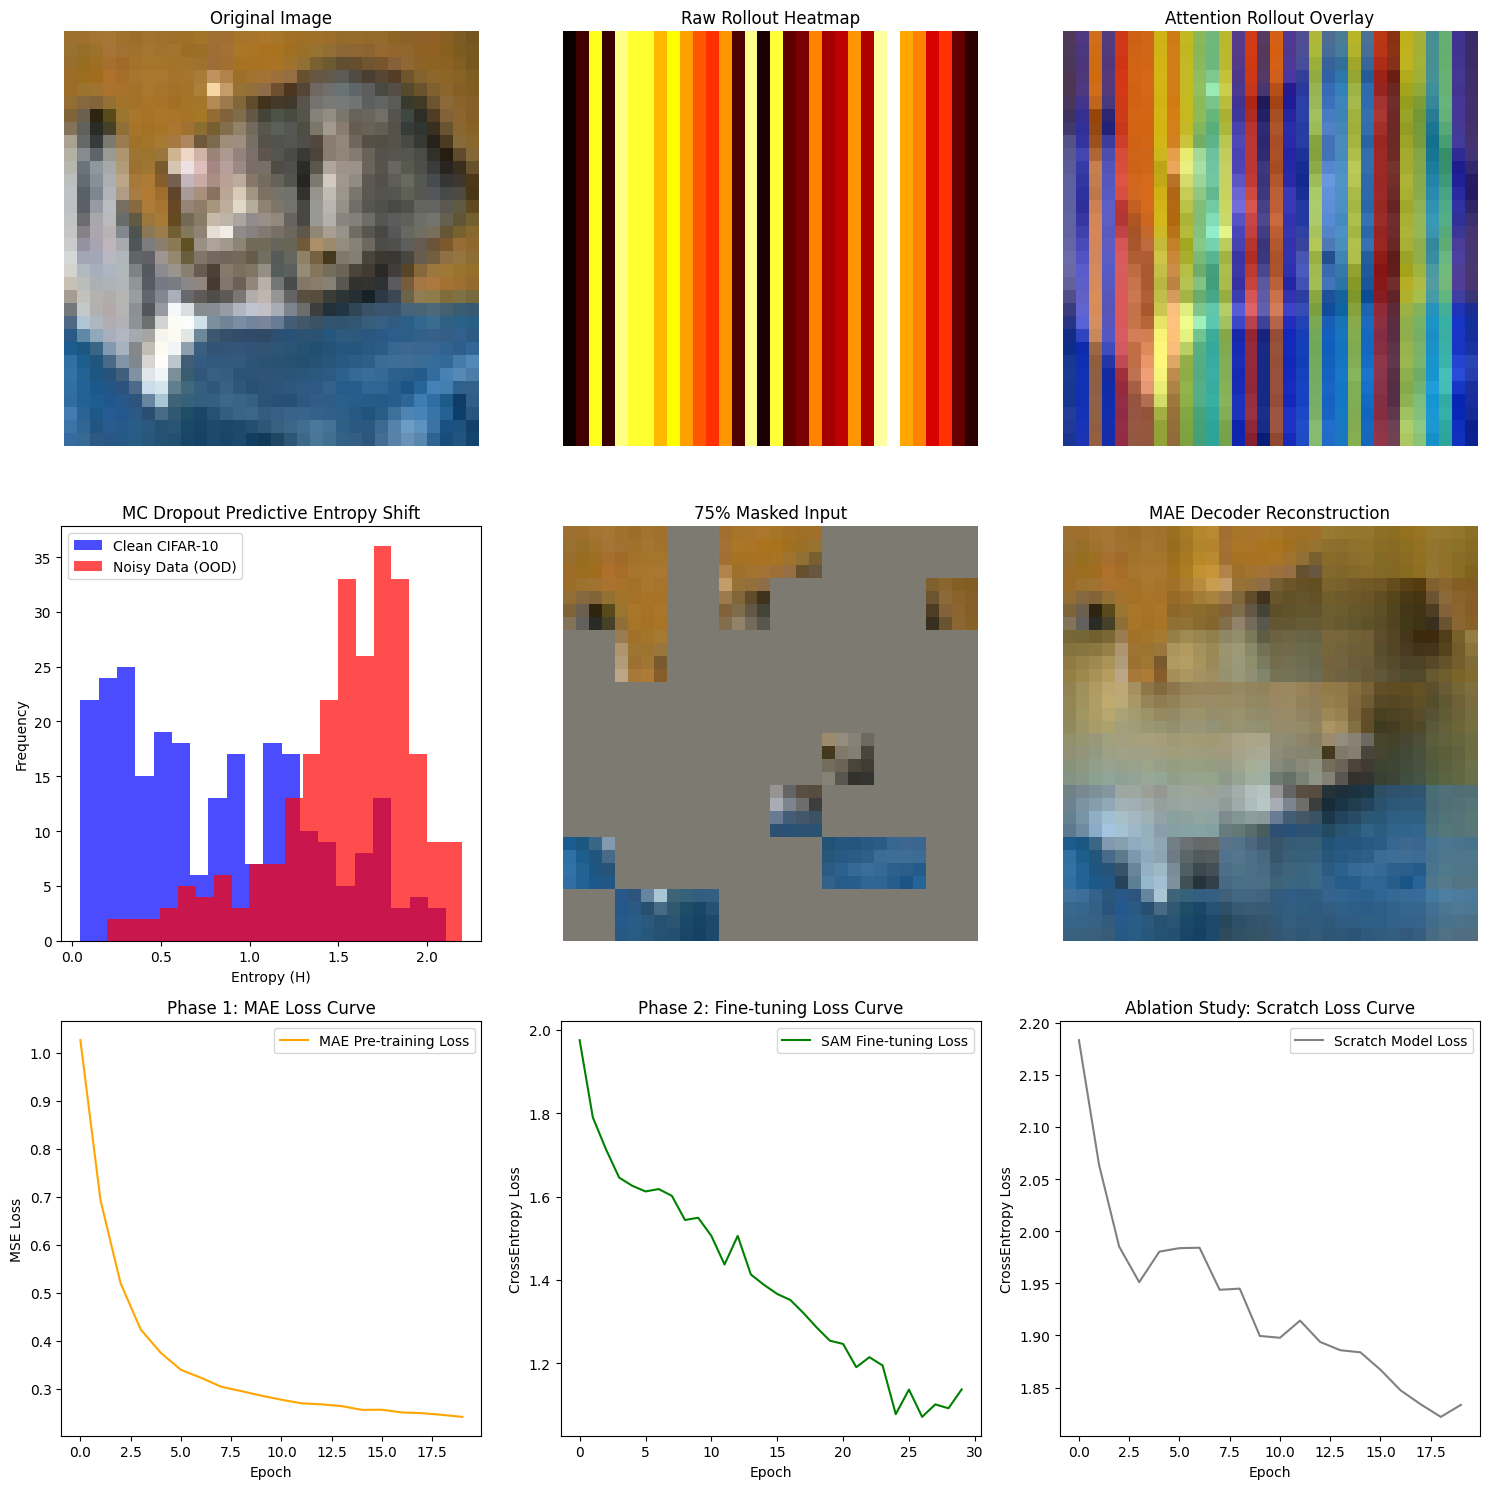

[*] Complete V3 Pipeline Successfully Executed and Evaluated.


In [ ]:
# Block 13: Final Visualizations

def show_image(tensor, ax, title=""):
    """De-normalizes and maps raw tensors to displayable arrays."""
    img = tensor.cpu().numpy().transpose(1, 2, 0)
    img = (img * cifar_std) + cifar_mean
    img = np.clip(img, 0, 1)
    ax.imshow(img)
    ax.set_title(title)
    ax.axis('off')

# Establish comprehensive plotting environment
fig, axes = plt.subplots(3, 3, figsize=(15, 15))

# 1. Visualization Mapping: Attention Rollout overlay mappings
idx = 0  # Isolate specific test sample index
img_display = imgs_clean[idx].numpy().transpose(1, 2, 0)
img_display = np.clip((img_display * cifar_std) + cifar_mean, 0, 1)
heatmap = rollout_upsampled[idx].numpy()
heatmap = (heatmap - heatmap.min()) / (heatmap.max() - heatmap.min() + 1e-8)

# Generate standardized cv2 colormap array
heatmap_color = cv2.applyColorMap(np.uint8(255 * heatmap), cv2.COLORMAP_JET)
heatmap_color = cv2.cvtColor(heatmap_color, cv2.COLOR_BGR2RGB) / 255.0
overlay = 0.5 * img_display + 0.5 * heatmap_color

show_image(imgs_clean[idx], axes[0, 0], title="Original Image")
axes[0, 1].imshow(heatmap, cmap='hot')
axes[0, 1].set_title("Raw Rollout Heatmap")
axes[0, 1].axis('off')
axes[0, 2].imshow(overlay)
axes[0, 2].set_title("Attention Rollout Overlay")
axes[0, 2].axis('off')

# 2. Visualization Mapping: Epistemic Uncertainty Histogram Verification
axes[1, 0].hist(entropy_clean, bins=20, alpha=0.7, color='blue', label='Clean CIFAR-10')
axes[1, 0].hist(entropy_noisy, bins=20, alpha=0.7, color='red', label='Noisy Data (OOD)')
axes[1, 0].set_title("MC Dropout Predictive Entropy Shift")
axes[1, 0].set_xlabel("Entropy (H)")
axes[1, 0].set_ylabel("Frequency")
axes[1, 0].legend()

# 3. Visualization Mapping: MAE Topography Check (Running Phase 1 Model on Clean Test Image)
if 'mae_model' in locals():
    mae_model.eval()
    with torch.no_grad():
        _, pred, mask = mae_model(imgs_clean[idx:idx+1].to(device))

        # Algorithmic reconstruction plotting array mapping
        p = CONFIG['patch_size']
        pred = pred.cpu().reshape(1, 8, 8, p, p, 3).permute(0, 5, 1, 3, 2, 4).reshape(1, 3, 32, 32)
        mask = mask.cpu().reshape(1, 8, 8).unsqueeze(-1).repeat(1, 1, 1, p**2 * 3)
        mask = mask.reshape(1, 8, 8, p, p, 3).permute(0, 5, 1, 3, 2, 4).reshape(1, 3, 32, 32)

        img_masked = imgs_clean[idx:idx+1] * (1 - mask)
        img_reconstructed = imgs_clean[idx:idx+1] * (1 - mask) + pred * mask

    show_image(img_masked[0], axes[1, 1], title="75% Masked Input")
    show_image(img_reconstructed[0], axes[1, 2], title="MAE Decoder Reconstruction")
else:
    axes[1, 1].text(0.5, 0.5, 'MAE Pre-training Skipped', ha='center', va='center', fontsize=12)
    axes[1, 1].axis('off')
    axes[1, 2].text(0.5, 0.5, 'MAE Pre-training Skipped', ha='center', va='center', fontsize=12)
    axes[1, 2].axis('off')

# 4. Training Loss Curves
if 'mae_losses' in locals() and len(mae_losses) > 0:
    axes[2, 0].plot(mae_losses, color='orange', label='MAE Pre-training Loss')
    axes[2, 0].set_title("Phase 1: MAE Loss Curve")
    axes[2, 0].set_xlabel("Epoch")
    axes[2, 0].set_ylabel("MSE Loss")
    axes[2, 0].legend()
else:
    axes[2, 0].text(0.5, 0.5, 'MAE Training Skipped', ha='center', va='center', fontsize=12)
    axes[2, 0].axis('off')

if 'ft_losses' in locals() and len(ft_losses) > 0:
    axes[2, 1].plot(ft_losses, color='green', label='SAM Fine-tuning Loss')
    axes[2, 1].set_title("Phase 2: Fine-tuning Loss Curve")
    axes[2, 1].set_xlabel("Epoch")
    axes[2, 1].set_ylabel("CrossEntropy Loss")
    axes[2, 1].legend()
else:
    axes[2, 1].text(0.5, 0.5, 'Fine-tuning Skipped', ha='center', va='center', fontsize=12)
    axes[2, 1].axis('off')

if 'scratch_losses' in locals() and len(scratch_losses) > 0:
    axes[2, 2].plot(scratch_losses, color='gray', label='Scratch Model Loss')
    axes[2, 2].set_title("Ablation Study: Scratch Loss Curve")
    axes[2, 2].set_xlabel("Epoch")
    axes[2, 2].set_ylabel("CrossEntropy Loss")
    axes[2, 2].legend()
else:
    axes[2, 2].text(0.5, 0.5, 'Ablation Study Skipped', ha='center', va='center', fontsize=12)
    axes[2, 2].axis('off')

plt.tight_layout()
plt.show()

print("Complete V3 Pipeline Successfully Executed and Evaluated.")